In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import sys
import os
import joblib
from tqdm import tqdm
from pathlib import Path

from plotting import plot_sagd_heatmap_row_with_prob, plot_breakpoint_and_speciation


In [2]:
ds = [2, 50, 256, 1024, 16384]

path = Path('../data/exp_01')

W_list = []
time_snaps_vector_list = []
ts_tuple_list = []
tsagd_tuple_list = []
std = 1.0
mu = None

for d_i in ds:
    ld = joblib.load(path / f"D{d_i}_N1000_T10/history.jbl")
    breakpoints = joblib.load(path / f"D{d_i}_N1000_T10/clusters.jbl")
    W_list.append(joblib.load(path / f"D{d_i}_N1000_T10/SAGD.jbl"))
    snaps = ld['params']['times_snapshots']
    t_s_i = ld['params']['ts_theoretical']
    mu = ld['params']['mu']
    time_snaps_vector_list.append(snaps)
    t_sagd_idx = breakpoints[0]
    t_sagd = snaps[t_sagd_idx]
    ts_tuple_list.append((t_s_i, int(np.argmin(np.abs(snaps - t_s_i)))))
    tsagd_tuple_list.append((t_sagd, t_sagd_idx))

/home/itolstoganov/miniforge3/envs/sagd-regimes/lib/python3.10/site-packages/ou_model.py:119: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integral = integrate.quad(part, x0, -x0, epsrel=1e-4)[0]
/home/itolstoganov/miniforge3/envs/sagd-regimes/lib/python3.10/site-packages/ou_model.py:119: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integral = integrate.quad(part, x0, -x0, epsrel=1e-4)[0]
/home/itolstoganov/miniforge3/envs/sagd-regimes/lib/python3.10/site-packages/ou_model.py:119: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integral = integrate.quad(part, x0, -x0, epsrel=1e-4)[0]


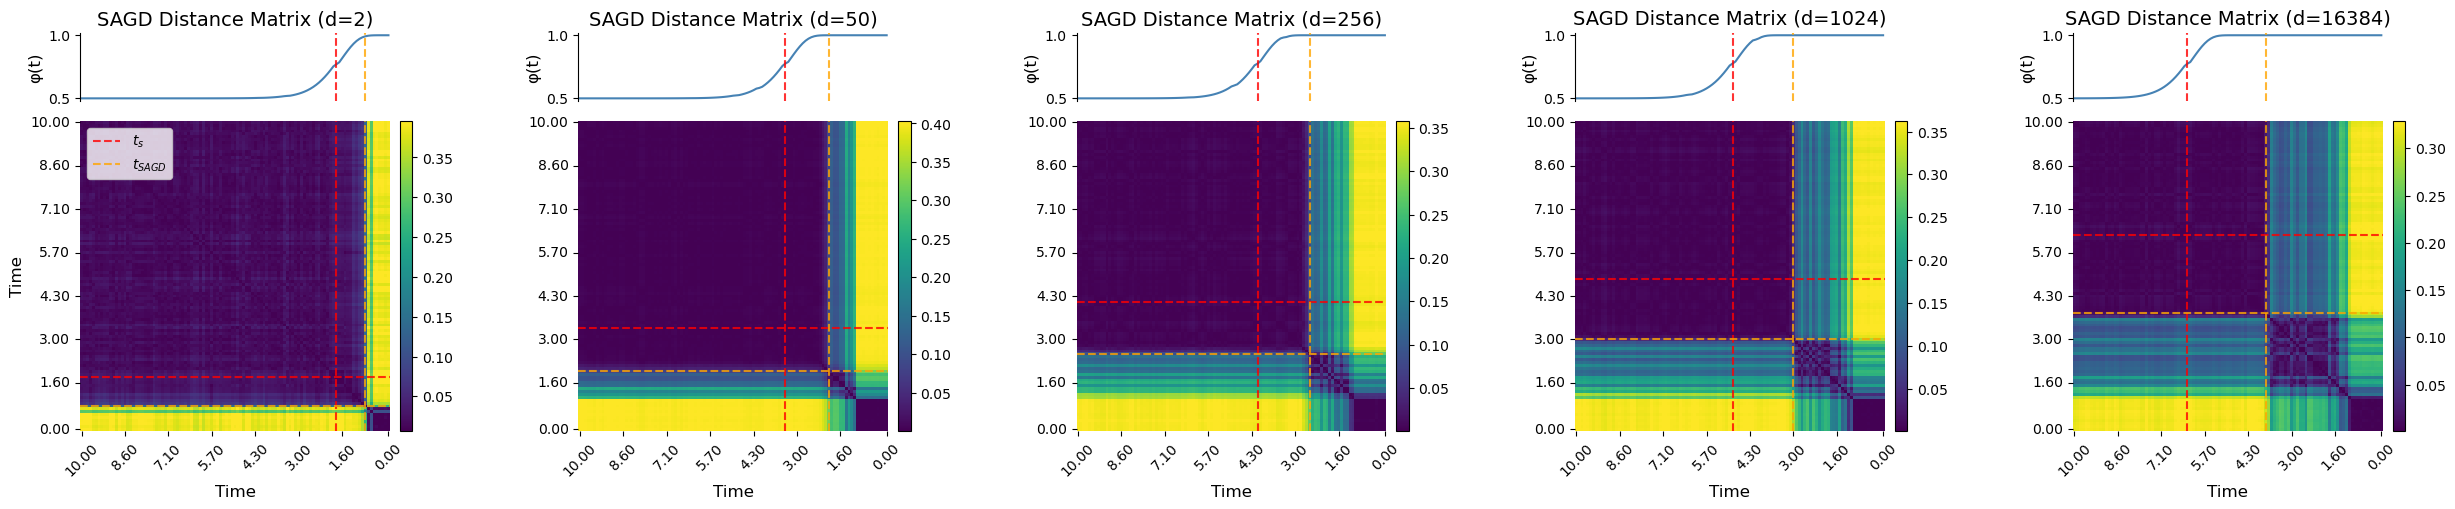

In [3]:
plot_sagd_heatmap_row_with_prob(
    W_list=W_list,
    d_list=ds,
    time_snaps_vector_list=time_snaps_vector_list,
    ts_tuple_list=ts_tuple_list,
    mu=mu,
    std=std,
    tsagd_tuple_list=tsagd_tuple_list,
    save_fig_path='../figures/sagd_heatmap_row_with_prob.png',
)

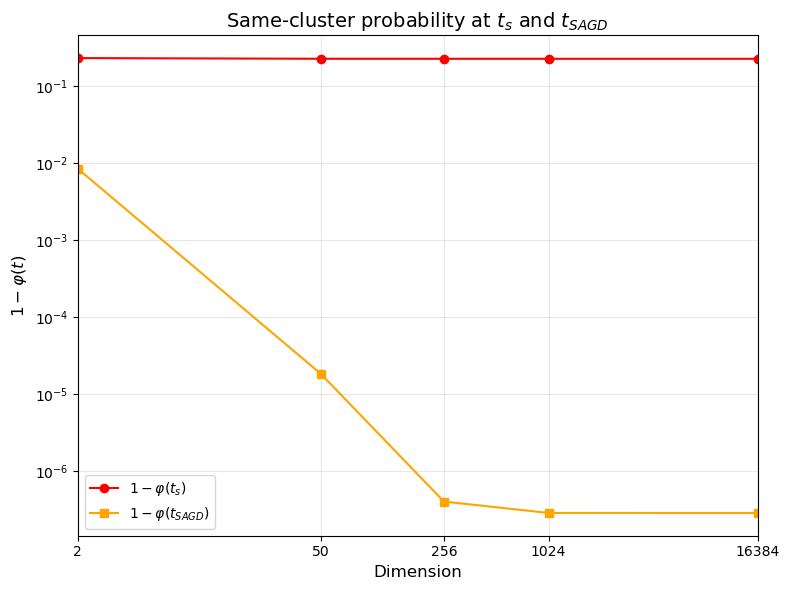

In [4]:
plot_breakpoint_and_speciation(
        d_list=ds,
        ts_tuple_list=ts_tuple_list,
        tsagd_tuple_list=tsagd_tuple_list,
        mu=mu,
        std=std,
        save_fig_path='../figures/speciation_and_sagd_times.png',
)